# Neural Network Classification: MNIST Dataset

이 노트북에서는 **MNIST 손글씨 숫자 (0~9)** 데이터셋을 활용하여 신경망 분류 모델을 학습합니다.

## 목표
1. 데이터 불러오기 및 전처리
2. Neural Network 모델 정의
3. 학습 및 학습 곡선 확인
4. 성능 평가 및 예측 시각화


In [1]:
# matplotlib 폰트 깨짐 현상 해결
import matplotlib.font_manager as fm
fm.fontManager.ttflist
[f.name for f in fm.fontManager.ttflist]

import matplotlib as mpl
mpl.rcParams['font.family'] = 'NanumGothic'

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

I0000 00:00:1789966402.047415    4091 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1789966403.449972    4091 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. 데이터 불러오기

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("원본 데이터 shape:", X_train.shape, y_train.shape)

원본 데이터 shape: (60000, 28, 28) (60000,)


## 2. 데이터 전처리

In [4]:
# 0~255 픽셀값 → 0~1 정규화
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# (28,28) → (784,) 벡터화
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# One-hot 인코딩
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("전처리 후 shape:", X_train.shape, y_train.shape)

전처리 후 shape: (60000, 784) (60000, 10)


## 3. 모델 정의

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(784,)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 4. 모델 컴파일

In [6]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

## 5. 모델 학습

In [7]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/10


  1/375 ━━━━━━━━━━━━━━━━━━━━ 4:31 725ms/step - accuracy: 0.0156 - loss: 2.3697

 15/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5932 - loss: 1.5672    

 31/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7119 - loss: 1.0712

 47/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7665 - loss: 0.8461

...

323/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9957 - loss: 0.0128

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9958 - loss: 0.0126

356/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9957 - loss: 0.0126

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9957 - loss: 0.0128

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9957 - loss: 0.0128 - val_accuracy: 0.9731 - val_loss: 0.1143


## 6. 학습 곡선 확인

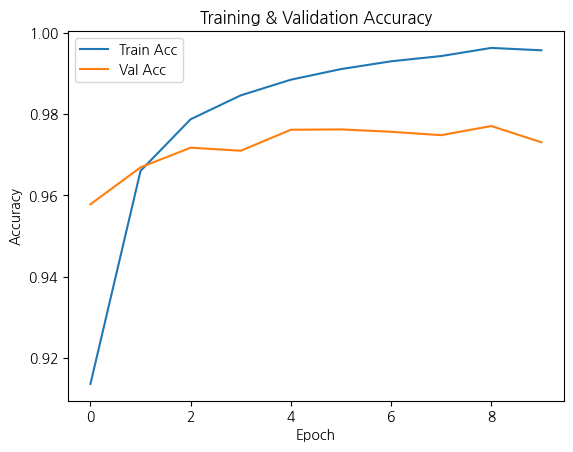

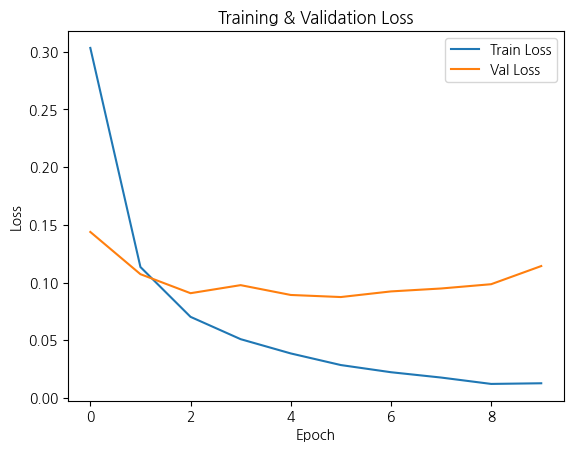

In [8]:
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.show()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.show()

## 7. 모델 평가

In [9]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"테스트 정확도: {acc:.3f}")

테스트 정확도: 0.975


## 8. 예측 예시 시각화

  1/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step

 46/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

 95/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

146/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

199/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

254/313 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step

305/313 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


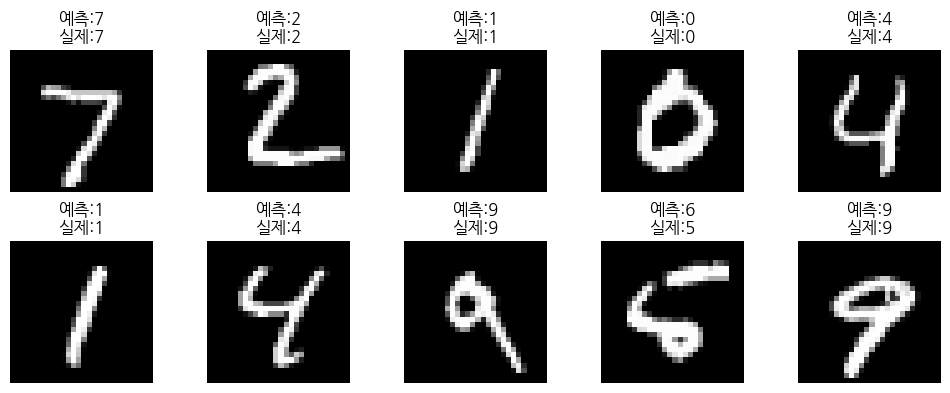

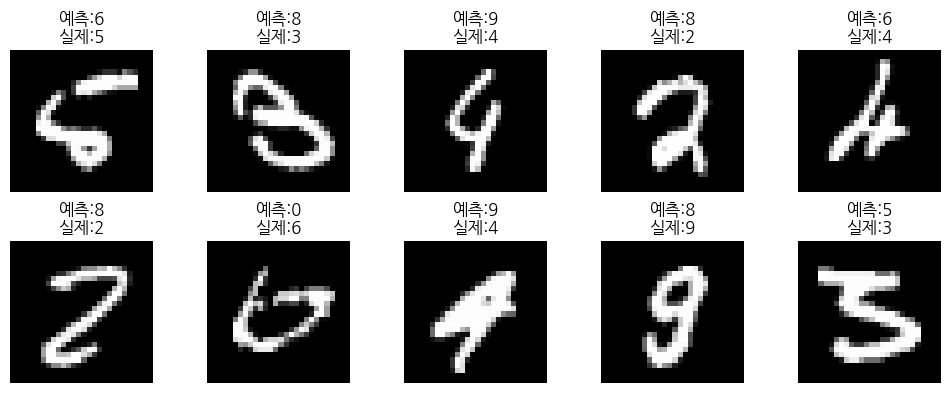

In [10]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

idx = 0
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i+idx].reshape(28,28), cmap="gray")
    plt.title(f"예측:{y_pred_classes[i+idx]}\n실제:{y_true[i+idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

failed = y_pred_classes != y_true
failed_idx = np.where(failed)[0]
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[failed_idx[i]].reshape(28,28), cmap="gray")
    plt.title(f"예측:{y_pred_classes[failed_idx[i]]}\n실제:{y_true[failed_idx[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## 생각해보기
- Training/Validation Graph 에서 과적합(overfitting) 징후가 보이나?

**답변 — 네, 과적합 징후가 분명하게 보입니다.**

**① 실행 결과: 6 epoch에서 검증 손실이 반전한다**

| Epoch | Train Loss | **Val Loss** | Train Acc | Val Acc |
|---|---|---|---|---|
| 1 | 0.3032 | 0.1438 | 0.9136 | 0.9578 |
| 2 | 0.1135 | 0.1072 | 0.9661 | 0.9669 |
| 3 | 0.0703 | 0.0908 | 0.9787 | 0.9718 |
| 4 | 0.0510 | 0.0977 | 0.9846 | 0.9710 |
| 5 | 0.0386 | 0.0892 | 0.9885 | 0.9762 |
| **6** | 0.0285 | **0.0874 ← 최저** | 0.9911 | 0.9762 |
| 7 | 0.0223 | 0.0923 ↑ | 0.9930 | 0.9757 |
| 8 | 0.0177 | 0.0948 ↑ | 0.9943 | 0.9748 |
| 9 | 0.0122 | 0.0986 ↑ | 0.9963 | 0.9771 |
| 10 | **0.0128** | **0.1143 ↑↑** | **0.9957** | 0.9731 |

**핵심은 두 곡선이 갈라지는 지점이다.**

- **Train Loss**는 10 epoch 내내 단조 감소한다 (0.3032 → 0.0128, 약 24분의 1).
- **Val Loss**는 6 epoch의 0.0874에서 **최저를 찍고 방향을 바꿔 상승**한다 (→ 0.1143, 약 31% 증가).

이 "훈련 손실은 계속 내려가는데 검증 손실은 올라가는" 갈라짐이 **강의 35p의 Training/Validation Loss Graph에 표시된 `Overfitting!` 지점과 정확히 같은 모양**이다. 7 epoch부터는 모델이 일반화되는 패턴이 아니라 **학습 데이터의 개별 특성을 외우기 시작한 것**이다.

**② 일반화 격차(generalization gap)**

- 정확도 기준: 99.57% vs 97.31% → **2.26%p 차이**
- 손실 기준: 0.0128 vs 0.1143 → **약 9배 차이**

**정확도보다 손실에서 과적합이 훨씬 먼저, 훨씬 뚜렷하게 드러난다.** 정확도는 "맞았나 틀렸나"만 보지만 손실은 "얼마나 확신하고 틀렸나"까지 보기 때문이다. 검증 정확도가 97% 근처에서 횡보하는 동안 검증 손실은 이미 올라가고 있었는데, 이는 **모델이 틀린 답에 점점 더 확신을 갖게 되었다**는 뜻이다. 그래서 학습 곡선은 정확도가 아니라 **손실로 판단해야 한다.**

**③ 원인 분석** (강의 33p의 두 가지 이유)

- **이유 2 — 모델의 복잡도:** 784→256→128→10 구조의 학습 파라미터는 **235,146개**(200,960 + 32,896 + 1,290)다. 학습에 실제로 쓰인 샘플은 48,000개(60,000의 80%)이므로 **파라미터가 샘플보다 약 5배 많다.** 데이터를 통째로 외울 수 있는 용량이다.
- **규제화 장치가 전혀 없음:** Dropout, L2 규제화, Batch Normalization, 데이터 증강 중 무엇도 적용되지 않았다.
- 다만 **이유 1(데이터 다양성 부족)은 해당하지 않는다.** MNIST는 6만 장으로 충분히 크고 다양해서, 과적합이 10 epoch 동안 완만하게만 진행되었다. 그래서 최종 테스트 정확도도 **0.975**로 아직 쓸 만한 수준이다.

**④ 어떻게 대응할 것인가** *(4주차 Learning Strategies 내용)*

| 방법 | 적용 |
|---|---|
| **Early Stopping** | `val_loss` 기준 `patience=2`로 6 epoch 근처에서 중단 — 지금 상태에서 가장 간단하고 효과가 확실하다 |
| **Dropout** | 은닉층 뒤에 `Dropout(0.2~0.5)` 추가 |
| **L2 규제화** | `Dense(..., kernel_regularizer=l2(1e-4))` |
| **데이터 증강** | 약간의 회전·이동·확대로 학습 데이터 다양성 확보 |
| **모델 축소** | 256/128 → 128/64 등으로 파라미터 수 감소 |

**참고** — 6 epoch에서 멈췄다면 검증 손실 0.0874로, 10 epoch까지 돌린 0.1143보다 **더 좋은 모델**을 얻을 수 있었다. **더 오래 학습시키는 것이 항상 더 좋은 모델을 뜻하지는 않는다**는 점이 이 실습의 핵심이다.